# 1. Import Dependency 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import tensorflow as tf
import os
import cv2
import time

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


I0000 00:00:1779013902.367993  773715 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Import Dataset

Sumber dataset: https://data.mendeley.com/datasets/p7j5jrsbbb/1  

Indonesian Sign Language Dataset: Alphabet Video is a dataset that consists of a video showing the hand movement of the 26 alphabets in Indonesian Sign Language. There are 40 videos for the alphabet 'A,' 73 for 'B,' 15 for 'C,' 'E,' and 'L' up to 'Z,' 16 videos for 'D,' 26 videos for 'F,' 20 videos for 'G,' 'H, and 'I,' 22 videos for 'J,' and 25 videos for 'K' in the dataset. All the videos are in '*.mov' format and can be extracted into frames using the open CV (Computer Vision) Library. The size of each video is 480 x 640 pixels, and the fps is 25 frames per second. The dataset is made by the research group in the Informatics Department at the University of Trunojoyo Madura.

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


# Inisialisasi Mediapipe Handmarker

In [4]:
import os
# Force software rendering for OpenGL to prevent libEGL hardware driver crashes
# os.environ["LIBGL_ALWAYS_SOFTWARE"] = "1"
# # Disable OpenCV from trying to use hardware-accelerated video/GUI backends
# os.environ["OPENCV_VIDEOIO_DEBUG"] = "1"
# os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
# Tell EGL to use the surfaceless platform to prevent MediaPipe EGL context crashes on Linux
os.environ["EGL_PLATFORM"] = "surfaceless"

In [5]:
DATA_PATH = 'dataset'


In [6]:
actions = np.array(['A', 'B', 'C', 'D', 
                    'E', 'F', 'G', 'H',
                    'I', 'J', 'K', 'L',
                    'M', 'N', 'O', 'P',
                    'Q', 'R', 'S', 'T',
                    'U', 'V', 'W', 'X',
                    'Y', 'Z']) # WAJIB DISESUAIKAN: label yang ada


In [7]:
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='handlandmarker/hand_landmarker.task',
                             delegate=BaseOptions.Delegate.GPU),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2) 

# 1. Open the landmarker ONCE outside the loops to prevent memory leak kernel crashes
with HandLandmarker.create_from_options(options) as landmarker: 
    
    # LOOP 1: Actions
    for action in actions: 
        action_path = os.path.join(DATA_PATH, action)
        if not os.path.exists(action_path):
            continue
            
        video_files = [f for f in os.listdir(action_path) if f.endswith('.MOV') or f.endswith('.MP4')]
        
        # LOOP 2: Videos
        for video_filename in video_files:
            video_path = os.path.join(action_path, video_filename)
            sequence_name = os.path.splitext(video_filename)[0]
            sequence_path = os.path.join(action_path, sequence_name)
            os.makedirs(sequence_path, exist_ok=True)
            
            cap = cv2.VideoCapture(video_path)
            
            frame_index = 0
            
            # LOOP 3: Frames
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                
                rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
                
                # Apply HandLandmarker using IMAGE mode (avoids timestamp issues)
                hand_landmarker_result = landmarker.detect(mp_image)
                
                # Extract points
                if hand_landmarker_result.hand_landmarks:
                    hand_landmarks = hand_landmarker_result.hand_landmarks[0]
                    keypoints = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks]).flatten()
                else:
                    keypoints = np.zeros(21 * 3) 
                
                # Save the array
                npy_path = os.path.join(sequence_path, f"{frame_index}.npy")
                np.save(npy_path, keypoints)
                
                frame_index += 1
                
            cap.release()

I0000 00:00:1779013906.088788  773831 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779013906.142278  773846 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 595.58.03), renderer: NVIDIA GeForce RTX 3070 Ti/PCIe/SSE2
W0000 00:00:1779013906.397163  773840 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
E0000 00:00:1779013906.401131  773846 tensor.cc:404] Tensors are designed for single writes. Multiple writes to a Tensor instance are not supported and may lead to undefined behavior due to lack of synchronization.


# Path for exported data, numpy arrays

# Actions that we try to detect

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

In [9]:
# Thirty videos worth of data
no_sequences = 30  

# Videos are going to be 25 frames in length
sequence_length = 25

label_map = {label:num for num, label in enumerate(actions)}

sequences, labels = [], []
for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path):
        continue
        
    for sequence in os.listdir(action_path):
        sequence_path = os.path.join(action_path, sequence)
        if not os.path.isdir(sequence_path):
            continue
            
        window = []
        # Mengambil file npy sebanyak sequence_length
        for frame_num in range(sequence_length):
            npy_file = os.path.join(sequence_path, f"{frame_num}.npy")
            if os.path.exists(npy_file):
                res = np.load(npy_file)
            else:
                # Padding pakai nol, jika framenya kurang dari 25
                res = np.zeros(21*3)
            window.append(res)
            
        sequences.append(window)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train: (413, 25, 63)
Shape of y_train: (413, 26)


In [10]:
# 1. Definisikan Arsitektur CNN + LSTM
model = Sequential()

# CNN Layers (untuk mengekstrak fitur spasial dari data urutan keypoint)
# WAJIB DISESUAIKAN: input_shape (jumlah_frame_per_video, jumlah_features_keypoints)
# Contoh ini memakai asusmsi 25 sequence frame, dengan 63 titik data matriks Mediapipe
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(25, 63)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))

# LSTM Layers (untuk mempelajari Temporal/Sequence pergerakan titik waktu)
model.add(LSTM(64, return_sequences=True, activation='relu'))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=False, activation='relu'))

# Dense Layers (Klasifikasi akhir)
num_classes = len(actions) # WAJIB DISESUAIKAN: Ganti dengan total label dari class/gerakan sign language anda.
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile Model
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()

/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779014274.038876  773715 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4319 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 25, 64)         │        12,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,282 (766.73 KB)

 Trainable params: 196,282 (766.73 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 3. Setup Callbacks & Lakukan Training 
log_dir = os.path.join('Logs')
os.makedirs(log_dir, exist_ok=True)

tb_callback = TensorBoard(log_dir=log_dir)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_test, y_test), 
    epochs=200, 
    callbacks=[tb_callback, early_stopping]
)



Epoch 1/200


I0000 00:00:1779014278.062480  786838 service.cc:153] XLA service 0x5a9498541a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779014278.062494  786838 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070 Ti, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779014278.124429  786838 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779014278.648086  786838 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779014278.786448  786838 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_3418_grad_3650_const_0__.36.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779014278.786563  786838 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_3247_grad_4042_const_0__.43.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779014278.786654  

 1/13 ━━━━━━━━━━━━━━━━━━━━ 2:58 15s/step - categorical_accuracy: 0.1875 - loss: 3.2569

I0000 00:00:1779014290.508860  786838 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1779014291.196946  786835 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_3418_grad_3650_const_0__.36.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779014291.197075  786835 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_3247_grad_4042_const_0__.43.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779014291.197159  786835 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5099__.58
I0000 00:00:1779014291.950717  786835 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779014293.696108  786835 dot_search_space.cc:240

13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - categorical_accuracy: 0.1308 - loss: 3.2538 - val_categorical_accuracy: 0.1154 - val_loss: 3.2604
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.1598 - loss: 3.2392 - val_categorical_accuracy: 0.1154 - val_loss: 3.2518
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.1477 - loss: 3.1904 - val_categorical_accuracy: 0.1154 - val_loss: 3.1770
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.1477 - loss: 3.0133 - val_categorical_accuracy: 0.1346 - val_loss: 3.1368
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.1598 - loss: 2.9354 - val_categorical_accuracy: 0.0865 - val_loss: 3.0109
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.1525 - loss: 2.8742 - val_categorical_accuracy: 0.1058 - val_loss: 3.0070
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.1671 - loss: 2.8341 - val_ca

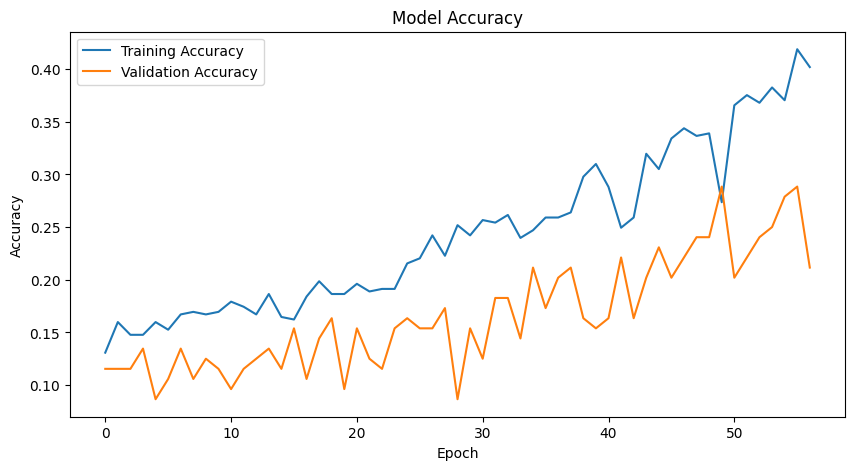

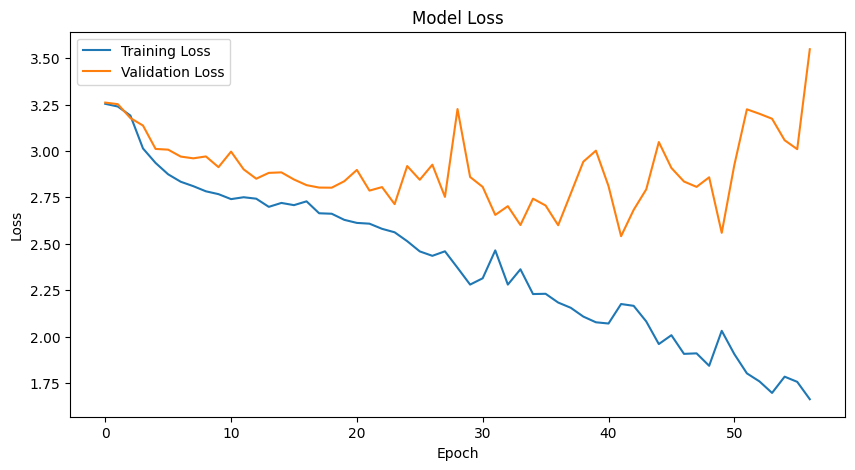

In [12]:
# Visualisasi Hasil Training
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step
================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         9
           B       0.22      0.58      0.32        12
           C       0.00      0.00      0.00         3
           D       0.00      0.00      0.00         4
           E       1.00      0.50      0.67         2
           F       0.00      0.00      0.00         4
           G       0.29      0.67      0.40         3
           H       0.00      0.00      0.00         5
           I       0.00      0.00      0.00         4
           J       0.36      0.67      0.47         6
           K       0.33      0.20      0.25         5
           L       0.00      0.00      0.00         3
           M       0.00      0.00      0.00         1
           N       0.25      0.25      0.25         4
           O       0.00      0.00      0.00         3
           P       0.18      0.67      0

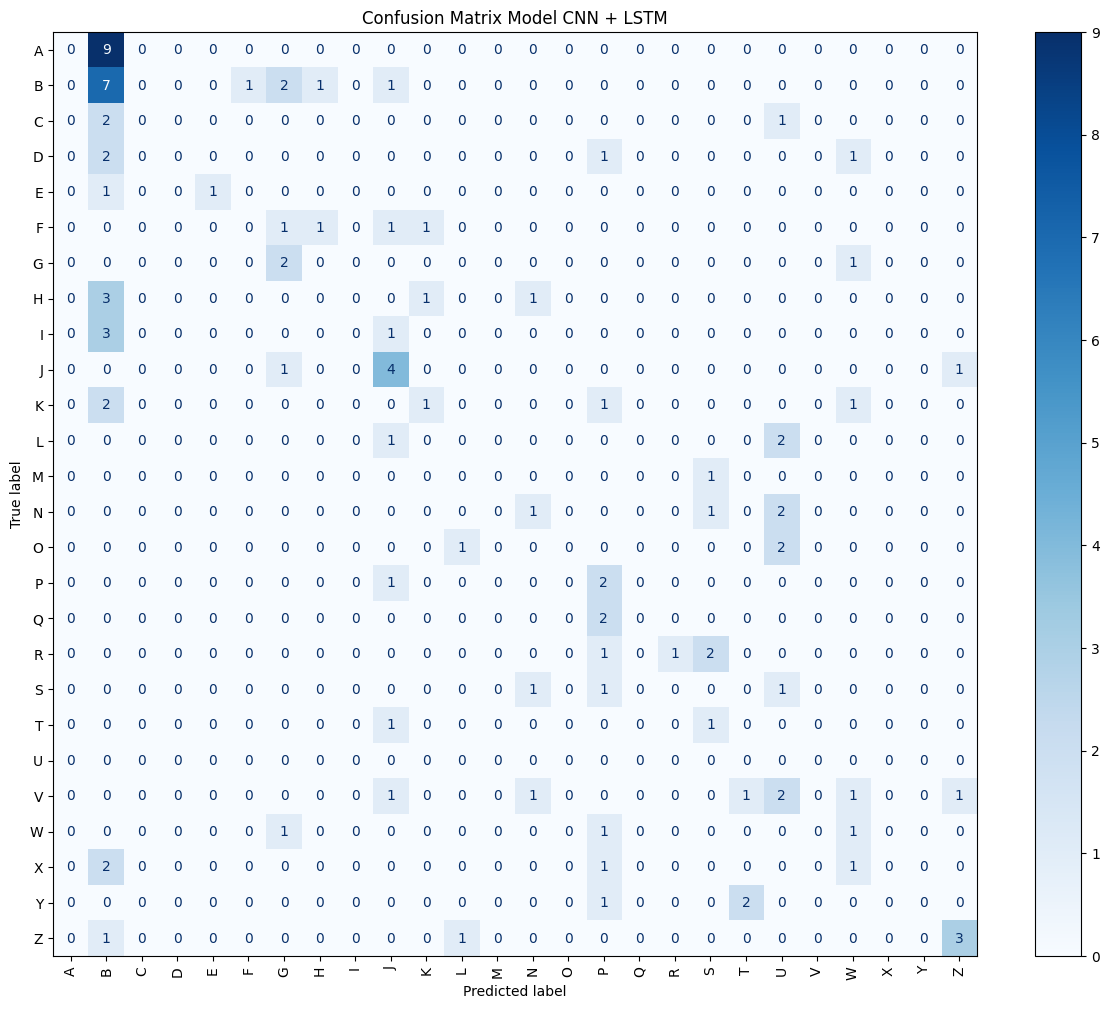

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Lakukan prediksi pada data pengujian (X_test)
y_pred = model.predict(X_test)

# 2. Konversi hasil probabilitas/one-hot ke label indeks integer (0-25 untuk A-Z)
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tambahkan argumen labels untuk memastikan semua 26 kelas (0 s.d 25) terhitung
label_indices = np.arange(len(actions))

# 3. Menampilkan Metrik Utama: Precision, Recall, F1-Score
print("================ CLASSIFICATION REPORT ================")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    labels=label_indices, 
    target_names=actions, 
    zero_division=0
))

# 4. Mendapatkan Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=label_indices)

# 5. Visualisasi Confusion Matrix dengan Matplotlib & scikit-learn
fig, ax = plt.subplots(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actions)

# Menyesuaikan label dan colormap
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix Model CNN + LSTM')
plt.show()

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Definisikan fungsi pembuatan model untuk Tuner
def build_model(hp):
    model = Sequential()
    
    # -- CNN Layers --
    # Tune jumlah filter untuk Conv1D lapisan pertama
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(Conv1D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same', input_shape=(25, 63)))
    model.add(MaxPooling1D(pool_size=2))
    
    # Tune jumlah filter untuk Conv1D lapisan kedua
    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=64)
    model.add(Conv1D(filters=hp_filters_2, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # Tune jumlah filter untuk Conv1D lapisan ketiga
    hp_filters_3 = hp.Int('filters_3', min_value=64, max_value=256, step=64)
    model.add(Conv1D(filters=hp_filters_3, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    
    # -- LSTM Layers --
    # Tune jumlah unit untuk LSTM pertama
    hp_lstm_1 = hp.Int('lstm_1', min_value=32, max_value=128, step=32)
    model.add(LSTM(hp_lstm_1, return_sequences=True, activation='relu'))
    
    # Tune nilai persentase Dropout
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.2, step=0.1)
    model.add(Dropout(hp_dropout))
    
    # Tune jumlah unit untuk LSTM kedua
    hp_lstm_2 = hp.Int('lstm_2', min_value=64, max_value=256, step=64)
    model.add(LSTM(hp_lstm_2, return_sequences=True, activation='relu'))

    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.2, step=0.1)
    model.add(Dropout(hp_dropout))

    # Tune jumlah unit untuk LSTM ketiga
    hp_lstm_3 = hp.Int('lstm_3', min_value=64, max_value=256, step=64)
    model.add(LSTM(hp_lstm_3, return_sequences=False, activation='relu'))
    
    
    # -- Dense Layers --
    # Tune jumlah unit untuk hidden Dense layer
    hp_dense_1 = hp.Int('dense_1', min_value=32, max_value=128, step=32)
    model.add(Dense(hp_dense_1, activation='relu'))
    model.add(Dense(32, activation='relu'))
    
    num_classes = len(actions) 
    model.add(Dense(num_classes, activation='softmax'))
    
    # -- Compile Model --
    # Mengunci nilai Learning Rate=0.01 secara spesifik
    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
    
    return model

# 2. Inisialisasi KerasTuner (Random Search)
tuner = kt.GridSearch(
    build_model,
    objective='val_categorical_accuracy',
    # max_trials=30,          # Berapa banyak kombinasi yang akan dicoba? (sesuaikan dengan kekuatan hardware)
    executions_per_trial=1, # Berapa kali melatih setiap kombinasi
    directory='Logs/Tuner',
    project_name='CNN_LSTM_SignLanguage',
    overwrite=True
)

# (Opsional) Tampilkan detail pencarian yang akan dilakukan
tuner.search_space_summary()

# 3. Mulai Proses Pencarian (Tuning)
early_stopping_tuner = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Memulai pencarian hyperparameter...")
tuner.search(
    X_train, 
    y_train, 
    epochs=50, # Epoch dibatasi secukupnya untuk mencoba masing-masing trial
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping_tuner],
)

# 4. Ambil dan tampilkan Hyperparameter Terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
- Filters Conv1D Pertama : {best_hps.get('filters_1')}
- Filters Conv1D Kedua   : {best_hps.get('filters_2')}
- Filters Conv1D Ketiga  : {best_hps.get('filters_3')}
- Units LSTM Pertama     : {best_hps.get('lstm_1')}
- Units LSTM Kedua       : {best_hps.get('lstm_2')}
- Units LSTM Ketiga      : {best_hps.get('lstm_3')}
- Rate Dropout           : {best_hps.get('dropout')}
- Units Dense            : {best_hps.get('dense_1')}
(Learning Rate tetap     : 0.01)
""")

# 5. Dapatkan Model Terbaik Secara Langsung
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 226 Complete [00h 00m 34s]
val_categorical_accuracy: 0.14423076808452606

Best val_categorical_accuracy So Far: 0.19230769574642181
Total elapsed time: 01h 37m 05s

Search: Running Trial #227

Value             |Best Value So Far |Hyperparameter
32                |32                |filters_1
64                |64                |filters_2
64                |64                |filters_3
64                |32                |lstm_1
0.2               |0.2               |dropout
192               |64                |lstm_2
64                |64                |lstm_3
96                |64                |dense_1



Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x7f4a3a7fc360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/weakref.py", line 369, in remove
    def remove(k, selfref=ref(self)):

KeyboardInterrupt: 


Epoch 1/50


I0000 00:00:1779020153.052621  786837 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_2659617_grad_2659849_const_0__.43.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779020153.052733  786837 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_2659446_grad_2660241_const_0__.49.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779020153.052819  786837 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_2659275_grad_2660632_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779020153.052919  786837 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2661900__.79


 1/13 ━━━━━━━━━━━━━━━━━━━━ 2:06 11s/step - categorical_accuracy: 0.0938 - loss: 3.2582